In [15]:
!pip install tf-levenberg-marquardt 

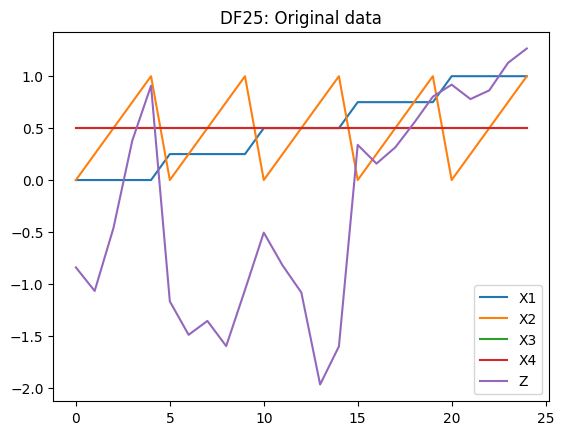

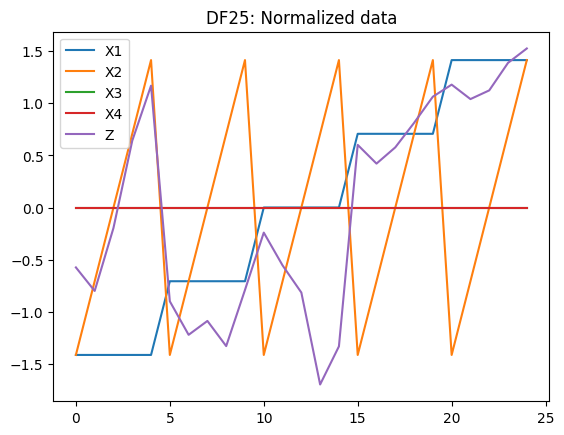

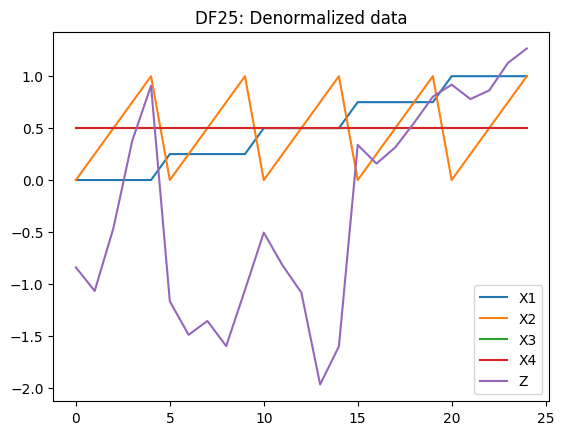

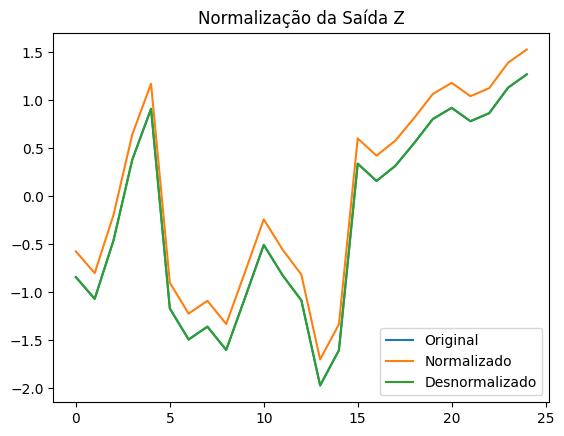

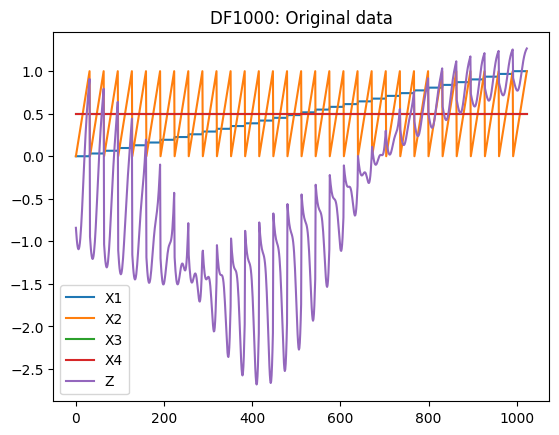

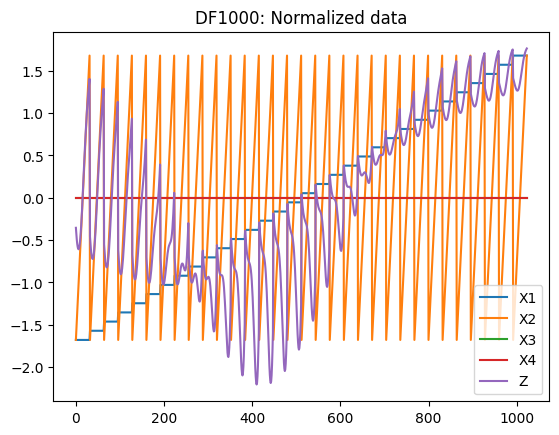

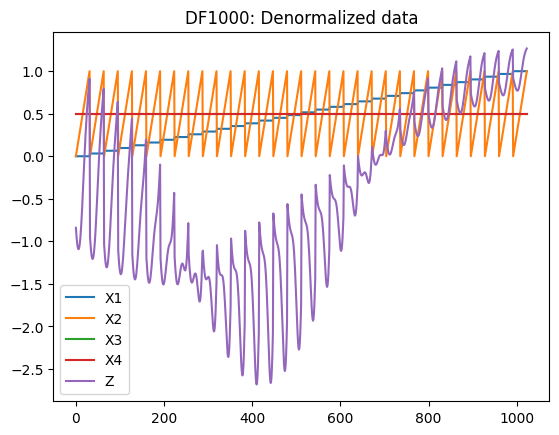

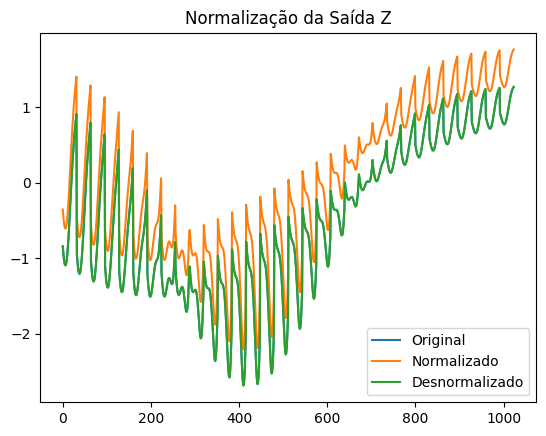

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Escaladores globais
scaler = StandardScaler()
out_scaler = StandardScaler()

# Função Hartmann4
def function(x):
    alpha = np.array([1.0, 1.2, 3.0, 3.2])
 
    A = np.array([
        [10,   3, 17, 3.5],
        [0.05, 10, 17, 0.1],
        [3, 3.5, 1.7, 10],
        [17,   8, 0.05, 10]
    ])

    P = 1e-4 * np.array([
        [1312, 1696, 5569, 124],
        [2329, 4135, 8307, 3736],
        [2348, 1451, 3522, 2883],
        [4047, 8828, 8732, 5743]
    ])

    x = np.asarray(x)
    if np.any((x < 0) | (x > 1)):
        raise ValueError("Todos os valores de x devem estar no intervalo [0, 1].")

    diff = x - P
    exp_term = np.exp(-np.sum(A * diff**2, axis=1))
    z = (1.1 - np.dot(alpha, exp_term)) / 0.839

    x1, x2, x3, x4 = x
    return z, x1, x2, x3, x4

# Criação do DataFrame com grid 2D (x1, x2), fixando x3, x4
def create_dataframe(grid, x3=0.5, x4=0.5):
    x_vals = np.linspace(0, 1, grid)
    data = []

    for x1 in x_vals:
        for x2 in x_vals:
            z, x1, x2, x3_val, x4_val = function([x1, x2, x3, x4])
            data.append([x1, x2, x3_val, x4_val, z])

    df = pd.DataFrame(data, columns=["X1", "X2", "X3", "X4", "Z"])
    return df

# Visualização da normalização
def show_norm(df, label="function", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if plot:
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
        plt.show()
    return df_norm

# Visualizar normalização da saída Z
def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)
    plt.figure()
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='Desnormalizado')
    plt.title("Normalização da Saída Z")
    plt.legend()
    plt.show()

# Execução dos testes
df_25 = create_dataframe(grid=5)
df_25_norm = show_norm(df_25, label="DF25", plot=True)
test_out_scaler(df_25)

df_1000 = create_dataframe(grid=32)
df_1000_norm = show_norm(df_1000, label="DF1000", plot=True)
test_out_scaler(df_1000)




In [29]:
def split_df(df):
    _input = np.vstack([df['X1'], df['X2'], df['X3'], df['X4']]).T
    _output = np.array(df['Z'])
    return (_input, _output)


In [30]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
            loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


In [34]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.cast(input, tf.float32)  # Mantém shape (N, 4)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)  # Output vira (N, 1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)
 
    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [37]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=4,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)

  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [41]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='mse',
            boundarie = 0.02,
            hidden_sizes = [[5, 4], [6, 6], [7, 7], [6, 4], [4, 5], [7, 6], [7, 4]],
            regularizers=[0.5, 0.03],
            learning_rate=[0.1, 0.05])

Testando combinacao1: Hidden Size=[5, 4], regularizer=0.5, learning_rate=0.1
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_2_2_14,0.982770,0.950588,0.847661,0.944349,0.909002,0.017082,0.048989,0.057715,0.036440,0.047078,0.340593,0.130700,1.013784,0.136264,116.139412,181.958706
model_2_2_13,0.982852,0.950581,0.849780,0.945982,0.910812,0.017001,0.048995,0.056912,0.035371,0.046142,0.343031,0.130388,1.013718,0.135939,116.148955,181.968250
model_2_2_15,0.982672,0.950574,0.845547,0.942762,0.907224,0.017180,0.049002,0.058516,0.037479,0.047998,0.338323,0.131072,1.013863,0.136652,116.128030,181.947325
model_2_2_12,0.982914,0.950550,0.851893,0.947658,0.912646,0.016939,0.049026,0.056112,0.034273,0.045193,0.345652,0.130151,1.013668,0.135692,116.156245,181.975539
model_2_2_16,0.982560,0.950543,0.843452,0.941222,0.905482,0.017291,0.049034,0.059310,0.038488,0.048899,0.336208,0.131494,1.013952,0.137092,116.115188,181.934483
model_2_2_17,0.982438,0.950496,0.841383,0.939730,0.903781,0.017412,0.049080,0.060093,0.039465,0.049779,0.334239,0.131954,1.014050,0.137572,116.101199,181.920494
model_2_2_11,0.982953,0.950490,0.853983,0.949373,0.914497,0.016901,0.049086,0.055320,0.033150,0.044235,0.348472,0.130003,1.013638,0.135538,116.160778,181.980072
model_2_2_18,0.982307,0.950438,0.839349,0.938288,0.902123,0.017542,0.049138,0.060864,0.040409,0.050636,0.332578,0.132445,1.014155,0.138083,116.086356,181.905650
model_2_2_10,0.982964,0.950397,0.856031,0.951124,0.916355,0.016890,0.049178,0.054544,0.032004,0.043274,0.351505,0.129963,1.013629,0.135496,116.162029,181.981323
model_2_2_19,0.982169,0.950369,0.837356,0.936896,0.900512,0.017678,0.049206,0.061619,0.041321,0.051470,0.331161,0.132958,1.014264,0.138618,116.070886,181.890181


DataFrame salvo em content/results/metrics_2_2
+++++++++++ [2_3] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_3] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_3] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_3] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_3] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_3] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_3] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_3] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [2_3] | 9 +++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_2_3_2,0.984284,0.950690,0.996377,0.839224,0.976725,0.015581,0.048887,0.007367,0.046783,0.027075,0.320315,0.124823,1.012572,0.130137,116.323420,182.142715
model_2_3_3,0.984800,0.950679,0.995776,0.839864,0.976280,0.015070,0.048899,0.008589,0.046597,0.027593,0.316962,0.122760,1.012160,0.127986,116.390101,182.209396
model_2_3_1,0.983682,0.950649,0.996935,0.838606,0.977136,0.016178,0.048929,0.006231,0.046963,0.026597,0.323812,0.127193,1.013054,0.132608,116.248209,182.067503
model_2_3_4,0.985238,0.950622,0.995145,0.840504,0.975809,0.014635,0.048955,0.009872,0.046411,0.028141,0.313767,0.120976,1.011809,0.126126,116.448656,182.267950
model_2_3_0,0.982981,0.950545,0.997437,0.838040,0.977504,0.016873,0.049031,0.005212,0.047128,0.026170,0.327436,0.129895,1.013615,0.135425,116.164113,181.983408
model_2_3_5,0.985609,0.950528,0.994494,0.841128,0.975318,0.014267,0.049048,0.011195,0.046229,0.028712,0.310737,0.119446,1.011512,0.124531,116.499572,182.318866
model_2_3_6,0.985921,0.950402,0.993832,0.841728,0.974814,0.013958,0.049174,0.012541,0.046054,0.029298,0.307976,0.118144,1.011263,0.123174,116.543392,182.362686
model_2_3_7,0.986181,0.950249,0.993166,0.842295,0.974303,0.013700,0.049325,0.013896,0.045890,0.029893,0.305369,0.117049,1.011055,0.122032,116.580651,182.399946
model_2_3_8,0.986396,0.950075,0.992502,0.842824,0.973789,0.013488,0.049498,0.015247,0.045736,0.030491,0.302915,0.116137,1.010884,0.121081,116.611930,182.431225
model_2_3_9,0.986570,0.949883,0.991844,0.843314,0.973275,0.013315,0.049688,0.016584,0.045593,0.031089,0.300606,0.115389,1.010744,0.120301,116.637788,182.457083


DataFrame salvo em content/results/metrics_2_3
+++++++++++ [2_4] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_4] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_4] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_4] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_4] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_4] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_4] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_4] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [2_4] | 9 +++++++++++

...

DataFrame salvo em content/results/metrics_28_7
+++++++++++ [28_8] | 1 ++++++++++++++++++
Stopped at epoch:  13
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_8] | 9 

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_8_0,0.996316,0.950261,0.987316,0.996572,0.990632,0.003652,0.049313,0.016150,0.002391,0.009270,0.066512,0.060436,1.001842,0.063008,155.224708,242.983767
model_28_8_1,0.996215,0.949989,0.986825,0.995977,0.990106,0.003752,0.049582,0.016776,0.002806,0.009791,0.067852,0.061254,1.001892,0.063862,155.170874,242.929933
model_28_8_2,0.996110,0.949719,0.986348,0.995372,0.989586,0.003856,0.049850,0.017382,0.003228,0.010305,0.069119,0.062099,1.001945,0.064743,155.116109,242.875169
model_28_8_3,0.996002,0.949452,0.985887,0.994765,0.989075,0.003964,0.050115,0.017970,0.003651,0.010811,0.070317,0.062957,1.001999,0.065638,155.061185,242.820245
model_28_8_4,0.995892,0.949189,0.985440,0.994159,0.988574,0.004073,0.050376,0.018539,0.004074,0.011307,0.071451,0.063821,1.002054,0.066538,155.006714,242.765774
model_28_8_5,0.995780,0.948931,0.985008,0.993559,0.988084,0.004184,0.050632,0.019089,0.004493,0.011791,0.072524,0.064681,1.002110,0.067435,154.953157,242.712216
model_28_8_6,0.995668,0.948678,0.984592,0.992967,0.987608,0.004294,0.050882,0.019619,0.004905,0.012262,0.073540,0.065532,1.002166,0.068322,154.900850,242.659909
model_28_8_7,0.995557,0.948431,0.984190,0.992386,0.987145,0.004405,0.051127,0.020131,0.005310,0.012721,0.074500,0.066370,1.002222,0.069195,154.850042,242.609101
model_28_8_8,0.995446,0.948191,0.983803,0.991818,0.986696,0.004515,0.051365,0.020623,0.005706,0.013165,0.075410,0.067190,1.002277,0.070051,154.800898,242.559957
model_28_8_9,0.995337,0.947958,0.983430,0.991265,0.986261,0.004623,0.051596,0.021098,0.006092,0.013595,0.076270,0.067991,1.002331,0.070885,154.753522,242.512582


DataFrame salvo em content/results/metrics_28_8
+++++++++++ [28_9] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [28_9] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [28_9] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_28_9_0,0.994526,0.945278,0.999298,0.987206,0.995211,0.005427,0.054253,0.000592,0.006192,0.003392,0.082043,0.073671,1.002737,0.076807,154.432588,242.191648
model_28_9_1,0.994981,0.945203,0.998898,0.988264,0.995334,0.004976,0.054328,0.000930,0.005680,0.003305,0.079366,0.070542,1.002510,0.073546,154.606161,242.365221
model_28_9_2,0.995378,0.945095,0.998431,0.989235,0.995388,0.004582,0.054434,0.001324,0.005210,0.003267,0.076944,0.067691,1.002311,0.070573,154.771218,242.530277
model_28_9_3,0.995725,0.944961,0.997912,0.990123,0.995382,0.004239,0.054567,0.001762,0.004780,0.003271,0.074648,0.065105,1.002138,0.067876,154.927045,242.686105
model_28_9_4,0.996026,0.944805,0.997351,0.990935,0.995326,0.003940,0.054722,0.002235,0.004387,0.003311,0.072471,0.062772,1.001987,0.065444,155.073003,242.832062
model_28_9_5,0.996286,0.944630,0.996758,0.991676,0.995226,0.003682,0.054895,0.002735,0.004028,0.003382,0.070435,0.060680,1.001857,0.063264,155.208532,242.967591
model_28_9_6,0.996510,0.944441,0.996142,0.992352,0.995089,0.003460,0.055083,0.003256,0.003702,0.003479,0.068574,0.058819,1.001745,0.061323,155.333193,243.092252
model_28_9_7,0.996703,0.944240,0.995509,0.992966,0.994922,0.003269,0.055282,0.003790,0.003404,0.003597,0.066811,0.057173,1.001649,0.059607,155.446674,243.205733
model_28_9_8,0.996867,0.944030,0.994866,0.993524,0.994729,0.003106,0.055491,0.004332,0.003134,0.003733,0.065138,0.055732,1.001566,0.058104,155.548833,243.307892
model_28_9_9,0.997006,0.943813,0.994217,0.994030,0.994516,0.002968,0.055705,0.004880,0.002889,0.003885,0.063550,0.054480,1.001497,0.056800,155.639665,243.398724


DataFrame salvo em content/results/metrics_28_9
